In [ ]:
from google.colab import files
uploaded = files.upload()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the uploaded CSV
df = pd.read_csv('delhivery_data.csv')

# Quick check
df.head()

,data,trip_creation_time,route_schedule_uuid,route_type,trip_uuid,source_center,source_name,destination_center,destination_name,od_start_time,...,cutoff_timestamp,actual_distance_to_destination,actual_time,osrm_time,osrm_distance,factor,segment_actual_time,segment_osrm_time,segment_osrm_distance,segment_factor
0,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:27:55,10.435660,14.0,11.0,11.9653,1.272727,14.0,11.0,11.9653,1.272727
1,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:17:55,18.936842,24.0,20.0,21.7243,1.200000,10.0,9.0,9.7590,1.111111
2,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 04:01:19.505586,27.637279,40.0,28.0,32.5395,1.428571,16.0,7.0,10.8152,2.285714
3,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:39:57,36.118028,62.0,40.0,45.5620,1.550000,21.0,12.0,13.0224,1.750000
4,training,2018-09-20 02:35:36.476840,thanos::sroute:eb7bfc78-b351-4c0e-a951-fa3d5c3...,Carting,trip-153741093647649320,IND388121AAA,Anand_VUNagar_DC (Gujarat),IND388620AAB,Khambhat_MotvdDPP_D (Gujarat),2018-09-20 03:21:32.418600,...,2018-09-20 03:33:55,39.386040,68.0,44.0,54.2181,1.545455,6.0,5.0,3.9153,1.200000


In [ ]:
#Converting and cleaning all string-like values in the DataFrame
df = df.astype(str).apply(lambda col: col.str.strip())

# Replacing placeholder missing values with 'Unknown'
df.replace(['nan', 'null', 'None', ''], 'Unknown', inplace=True)

# Replacing actual NaNs (if any remain)
df.replace(np.nan, 'Unknown', inplace=True)

In [ ]:
# Converting timestamp strings to datetime format
datetime_cols = ['trip_creation_time', 'od_start_time', 'od_end_time', 'cutoff_timestamp']
df[datetime_cols] = df[datetime_cols].apply(pd.to_datetime, errors='coerce')

In [ ]:
df[datetime_cols].dtypes

,0
trip_creation_time,datetime64[ns]
od_start_time,datetime64[ns]
od_end_time,datetime64[ns]
cutoff_timestamp,datetime64[ns]


In [ ]:
df.dtypes

,0
data,object
trip_creation_time,datetime64[ns]
route_schedule_uuid,object
route_type,object
trip_uuid,object
source_center,object
source_name,object
destination_center,object
destination_name,object
od_start_time,datetime64[ns]


In [ ]:
# Converting numeric columns to float
numeric_columns = [
    'start_scan_to_end_scan', 'cutoff_factor', 'actual_distance_to_destination',
    'actual_time', 'osrm_time', 'osrm_distance', 'factor',
    'segment_actual_time', 'segment_osrm_time', 'segment_osrm_distance', 'segment_factor'
]

df[numeric_columns] = df[numeric_columns].apply(pd.to_numeric, errors='coerce')

# Converting is_cutoff to boolean
df['is_cutoff'] = df['is_cutoff'].map({'True': True, 'False': False, 'Unknown': np.nan})


In [ ]:
# Extracting useful features from trip_creation_time
df['trip_year'] = df['trip_creation_time'].dt.year
df['trip_month'] = df['trip_creation_time'].dt.month
df['trip_day'] = df['trip_creation_time'].dt.day
df['trip_hour'] = df['trip_creation_time'].dt.hour
df['trip_weekday'] = df['trip_creation_time'].dt.dayofweek

In [ ]:
# Extracting state from within parentheses
df['source_state'] = df['source_name'].str.extract(r'\((.*?)\)')
df['destination_state'] = df['destination_name'].str.extract(r'\((.*?)\)')

# Extracting city/place before parentheses or space
df['source_city'] = df['source_name'].str.extract(r'^([^\(]+)')[0].apply(str.strip)
df['destination_city'] = df['destination_name'].str.extract(r'^([^\(]+)')[0].apply(str.strip)

In [ ]:
# Calculate delivery time in minutes
df['delivery_time'] = (df['od_end_time'] - df['od_start_time']).dt.total_seconds() / 60

**Analysis**

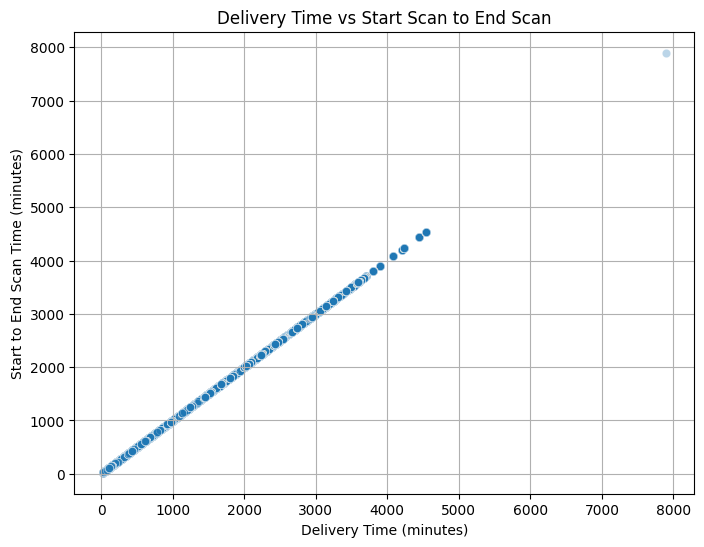

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='delivery_time', y='start_scan_to_end_scan', data=df, alpha=0.3)
plt.title('Delivery Time vs Start Scan to End Scan')
plt.xlabel('Delivery Time (minutes)')
plt.ylabel('Start to End Scan Time (minutes)')
plt.grid(True)
plt.show()

# **Insights from the Graph**

* Both times match well: Delivery time and scan time are almost the same for most trips.

* System is reliable: Scanning system is doing a good job tracking actual delivery time.

* One or two trips look odd: A few deliveries took much longer — these may be errors or delays.



# Compare actual_time vs osrm_time

In [ ]:
# Group by trip_uuid and sum actual and OSRM times
trip_times = df.groupby('trip_uuid')[['actual_time', 'osrm_time']].sum().reset_index()

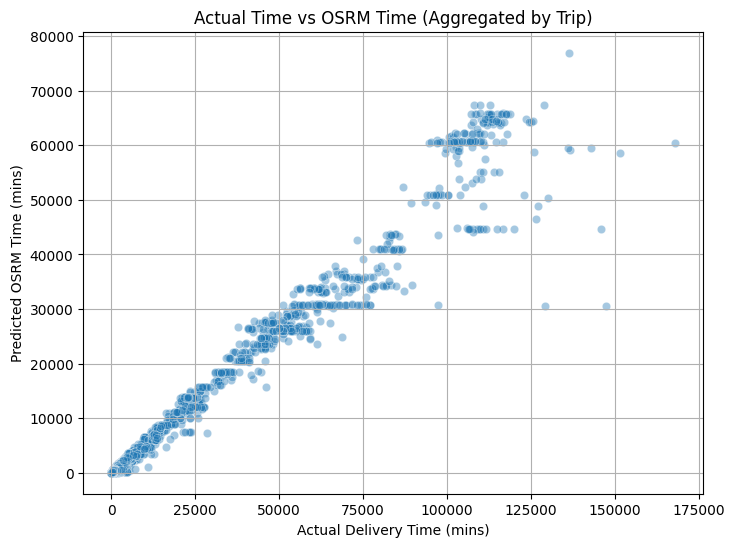

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='actual_time', y='osrm_time', data=trip_times, alpha=0.4)
plt.title('Actual Time vs OSRM Time (Aggregated by Trip)')
plt.xlabel('Actual Delivery Time (mins)')
plt.ylabel('Predicted OSRM Time (mins)')
plt.grid(True)
plt.show()


# **Insights: Actual Time vs OSRM Time (Trip Aggregated)**

1. Strong overall correlation: Most trips follow a linear trend, actual delivery time matches predicted time fairly well.

2. Actual time often higher than predicted: Many points lie below the diagonal line, means actual delivery took longer than OSRM’s prediction.

3. Some extreme outliers: A few trips took much longer than predicted — possible delays, traffic, or operational issues.

# Business Insight
Delhivery’s actual delivery performance is mostly aligned with routing estimates, but some trips show delays — possibly due to real-world conditions not captured by OSRM.

# Compare actual_time vs segment_actual_time (Aggregated)

In [ ]:
# Group by trip and sum both actual time and segment actual time
segment_check = df.groupby('trip_uuid')[['actual_time', 'segment_actual_time']].sum().reset_index()

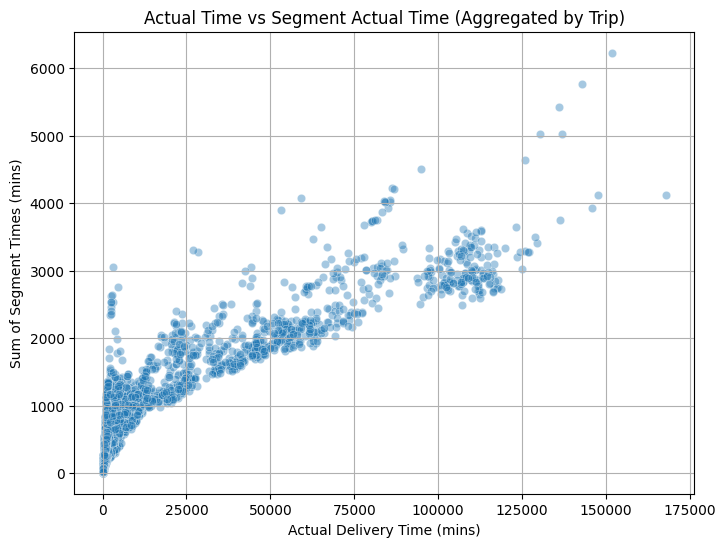

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='actual_time', y='segment_actual_time', data=segment_check, alpha=0.4)
plt.title('Actual Time vs Segment Actual Time (Aggregated by Trip)')
plt.xlabel('Actual Delivery Time (mins)')
plt.ylabel('Sum of Segment Times (mins)')
plt.grid(True)
plt.show()

# Insight from the Graph:
* The total trip time is usually more than the sum of all segment times.

* So, some delays are not captured in the segment data.

* The system may miss time spent between segments (like waiting or idle time).

# Business Insight:
* Segment-level tracking doesn’t fully explain total trip time.
* There may be inefficiencies or unrecorded delays between segments.

# OSRM Distance vs Segment OSRM Distance (Aggregated)

In [ ]:
# Group by trip and sum both OSRM distances
distance_check = df.groupby('trip_uuid')[['osrm_distance', 'segment_osrm_distance']].sum().reset_index()

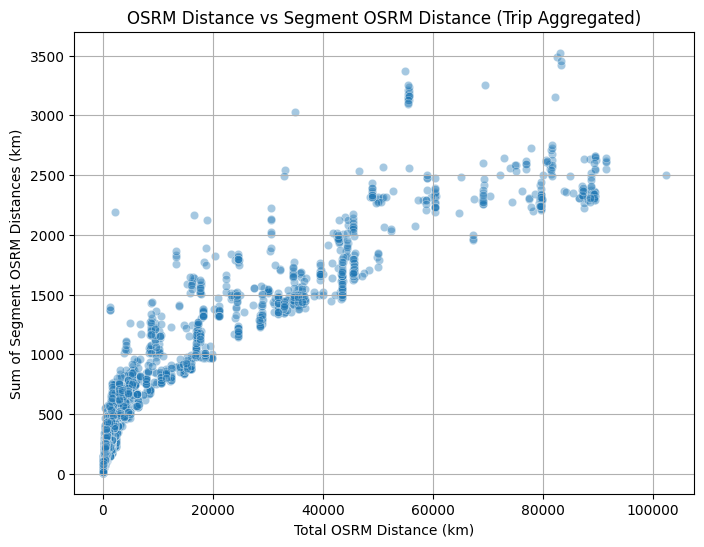

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='osrm_distance', y='segment_osrm_distance', data=distance_check, alpha=0.4)
plt.title('OSRM Distance vs Segment OSRM Distance (Trip Aggregated)')
plt.xlabel('Total OSRM Distance (km)')
plt.ylabel('Sum of Segment OSRM Distances (km)')
plt.grid(True)
plt.show()


**Insight**:
The total OSRM distance is much higher than the sum of segment distances for many trips.

This means:

➤ Some segments may be missing

➤ Or the segments are not covering the full route

➤ Or the system isn’t tracking the whole distance

Compare osrm_time vs segment_osrm_time (Aggregated)**bold text**

In [ ]:
# Group by trip and sum both OSRM times
osrm_time_check = df.groupby('trip_uuid')[['osrm_time', 'segment_osrm_time']].sum().reset_index()


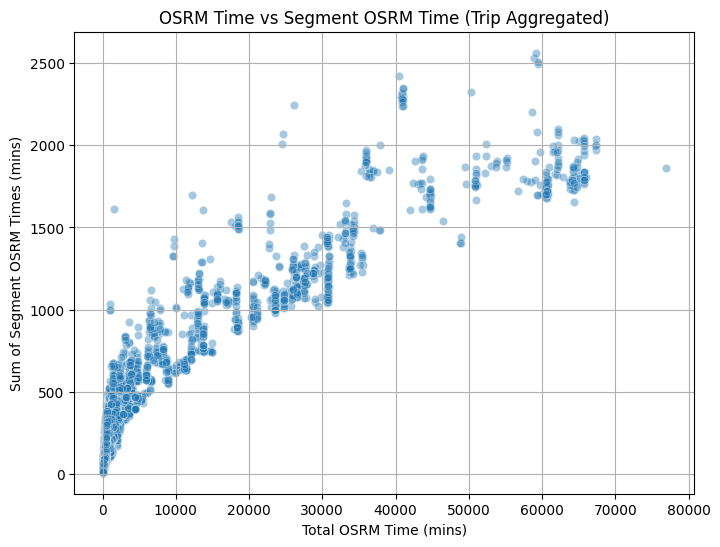

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='osrm_time', y='segment_osrm_time', data=osrm_time_check, alpha=0.4)
plt.title('OSRM Time vs Segment OSRM Time (Trip Aggregated)')
plt.xlabel('Total OSRM Time (mins)')
plt.ylabel('Sum of Segment OSRM Times (mins)')
plt.grid(True)
plt.show()

**Insight**:
The total predicted time from OSRM is higher than the sum of segment predicted times in many cases.

This means:

* Either some segments are missing

* Or segments are underestimating the actual trip time

* Prediction at trip level seems more reliable than segment level



# Outlier Detection & Handling

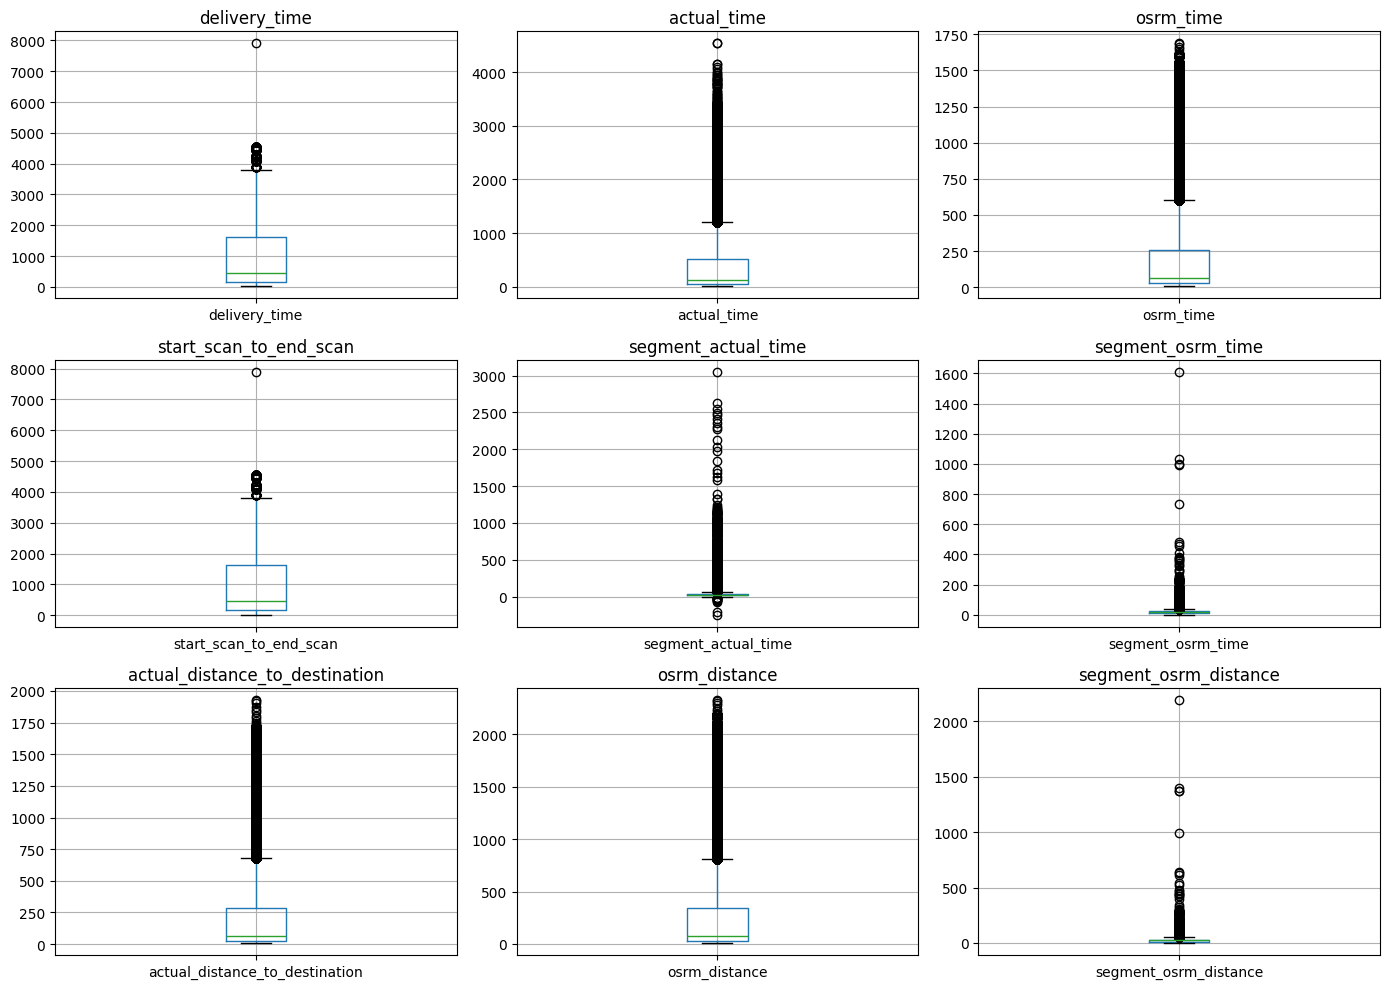

In [ ]:
numeric_cols = [
    'delivery_time', 'actual_time', 'osrm_time', 'start_scan_to_end_scan',
    'segment_actual_time', 'segment_osrm_time', 'actual_distance_to_destination',
    'osrm_distance', 'segment_osrm_distance'
]

# Plot boxplots
plt.figure(figsize=(14, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    df.boxplot(column=col)
    plt.title(col)

plt.tight_layout()
plt.show()

**Outlier Insights**

Almost every numeric column has a few very high outliers.

Most values are clustered at the bottom, and a few extreme points are far away (especially in time and distance).

In [ ]:
# IQR method to cap outliers
def cap_outliers(col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = np.where(df[col] < lower_bound, lower_bound,
                       np.where(df[col] > upper_bound, upper_bound, df[col]))

# Apply to key numeric columns
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')  # ensure numeric before processing
    cap_outliers(col)


# Handle Categorical Variables

In [ ]:
# One-hot encode 'route_type'
df = pd.get_dummies(df, columns=['route_type'], prefix='route')

# Normalize / Standardize Numeric Columns

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select numeric columns to scale
scale_cols = [
    'delivery_time', 'actual_time', 'osrm_time', 'start_scan_to_end_scan',
    'segment_actual_time', 'segment_osrm_time', 'actual_distance_to_destination',
    'osrm_distance', 'segment_osrm_distance'
]

# Create a copy of scaled values
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df[scale_cols])

# Replace original columns with scaled ones (optional)
df[scale_cols] = scaled_values

In [ ]:
# From where are most orders coming?
df['source_city'].value_counts().head(10)

,count
source_city,
Gurgaon_Bilaspur_HB,23347
Bangalore_Nelmngla_H,9975
Bhiwandi_Mankoli_HB,9088
Pune_Tathawde_H,4061
Hyderabad_Shamshbd_H,3340
Kolkata_Dankuni_HB,2612
Chandigarh_Mehmdpur_H,2450
Surat_HUB,2189
Delhi_Airport_H,2013


In [ ]:
#What are the busiest delivery corridors?

df['corridor'] = df['source_city'] + " ➝ " + df['destination_city']
df['corridor'].value_counts().head(10)

,count
corridor,
Gurgaon_Bilaspur_HB ➝ Bangalore_Nelmngla_H,4976
Bangalore_Nelmngla_H ➝ Gurgaon_Bilaspur_HB,3316
Gurgaon_Bilaspur_HB ➝ Kolkata_Dankuni_HB,2862
Gurgaon_Bilaspur_HB ➝ Hyderabad_Shamshbd_H,1639
Gurgaon_Bilaspur_HB ➝ Bhiwandi_Mankoli_HB,1617
Bhiwandi_Mankoli_HB ➝ Gurgaon_Bilaspur_HB,1269
Guwahati_Hub ➝ Delhi_Airport_H,1137
Bhiwandi_Mankoli_HB ➝ Bangalore_Nelmngla_H,1131
Gurgaon_Bilaspur_HB ➝ Pune_Tathawde_H,1120


In [ ]:
# What’s the average distance and time for top corridors?

df.groupby('corridor')[['actual_distance_to_destination', 'delivery_time']].mean().sort_values(
    by='delivery_time', ascending=False).head(10)

,actual_distance_to_destination,delivery_time
corridor,,
Chandigarh_Mehmdpur_H ➝ Bangalore_Nelmngla_H,1.737713,2.749439
Delhi_Airport_H ➝ Guwahati_Hub,1.447628,2.653517
Bangalore_Nelmngla_H ➝ Kolkata_Dankuni_HB,1.484450,2.549539
Guwahati_Hub ➝ Delhi_Airport_H,1.437484,2.515016
Kolkata_Dankuni_HB ➝ Bhiwandi_Mankoli_HB,1.505889,2.513216
Gurgaon_Bilaspur_HB ➝ MAA_Poonamallee_HB,1.533684,2.272020
Chandigarh_Mehmdpur_H ➝ Bhiwandi_Mankoli_HB,1.349884,2.261269
Bhiwandi_Mankoli_HB ➝ Kolkata_Dankuni_HB,1.500378,2.135879
Bengaluru_Nelmngla_L ➝ Gurgaon_Bilaspur_HB,1.530249,2.109289


# Business Insights
1. **Top Origin Locations**

  Most shipments originate from:


* Gurgaon_Bilaspur_HB

* Bangalore_Nelmngla_H

* Bhiwandi_Mankoli_HB

2. **Busiest Corridors**


The most active route is: Gurgaon_Bilaspur_HB to Bangalore_Nelmngla_H (4,976 trips)


Other high-volume corridors include routes between Gurgaon, Bangalore, Hyderabad, and Kolkata.


3. **Longest Average Delivery Times**


The corridors with the longest average delivery durations include:

* Chandigarh to Bangalore

* Delhi to Guwahati

* Bangalore to Kolkata

4. **High-Load Hubs**

Gurgaon_Bilaspur_HB appears as a hub in most busiest corridors, both as source and destination.

# Business Recommendations
* Focus on high-volume corridors like Gurgaon to Bangalore, as delays here impact operations significantly.

* Investigate long-duration corridors such as Chandigarh to Bangalore and Delhi to Guwahati for potential route or scheduling improvements.

* Improve scan tracking between segments to reduce the mismatch between actual time and segment time.

* Set up automatic alerts for trips where actual delivery time is much higher than expected.

* Use large differences between OSRM time/distance and actuals to identify and fix inefficiencies in routing or traffic handling.